In [5]:
from kiteconnect import KiteConnect

API_KEY = ""
API_SECRET = ""

kite = KiteConnect(api_key=API_KEY)

# Step 1: Get login URL
print("Login URL:", kite.login_url())

Login URL: https://kite.zerodha.com/connect/login?api_key=&v=3


In [ ]:
request_token = ""

data = kite.generate_session(request_token, api_secret=API_SECRET)

access_token = data["access_token"]

print("Access Token:", access_token)

kite.set_access_token(access_token)

Access Token: OXt1W34Lefrzt6qHFXdt3IVvRjtQHS58


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
NIFTY50 = [
    "RELIANCE.NS",
    "INFY.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

In [4]:
def fetch_data(ticker):
    df = yf.download(
        ticker,
        period="1d",
        interval="5m",
        progress=False
    )

    if df.empty:
        print(f"No data for {ticker}")
        return None

    return df.dropna()

In [5]:
df = fetch_data("INFY.NS")
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Datetime,,,,,
2026-04-17 09:35:00+00:00,1318.199951,1319.199951,1317.400024,1318.900024,302221
2026-04-17 09:40:00+00:00,1318.699951,1318.800049,1317.900024,1318.199951,259774
2026-04-17 09:45:00+00:00,1318.699951,1318.900024,1318.300049,1318.800049,306320
2026-04-17 09:50:00+00:00,1320.000000,1321.000000,1318.199951,1318.599976,288188
2026-04-17 09:55:00+00:00,1320.800049,1321.000000,1318.800049,1320.099976,267404


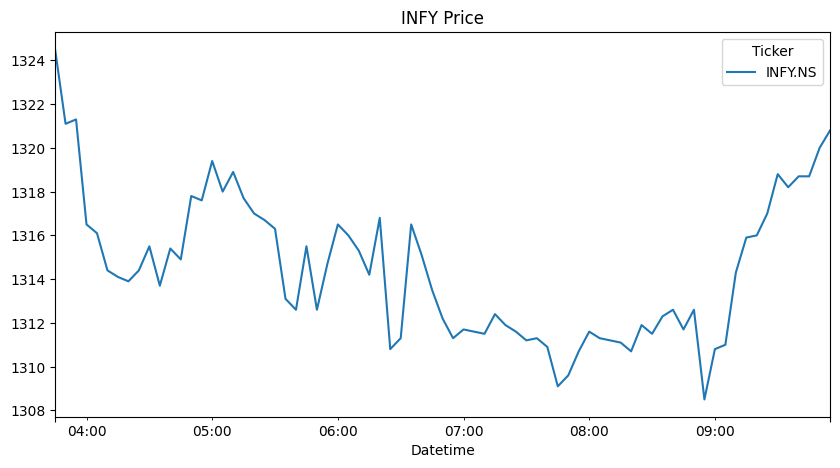

In [6]:
df["Close"].plot(figsize=(10,5), title="INFY Price")
plt.show()

In [7]:
data = {}

for stock in NIFTY50:
    print(f"Fetching {stock}...")
    df = fetch_data(stock)

    if df is not None:
        data[stock] = df
        print(df.tail(1))
        print("-" * 40)

Fetching RELIANCE.NS...
Price                           Close        High          Low         Open  \
Ticker                    RELIANCE.NS RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
Datetime                                                                      
2026-04-17 09:55:00+00:00      1364.5      1365.5  1363.099976  1365.099976   

Price                          Volume  
Ticker                    RELIANCE.NS  
Datetime                               
2026-04-17 09:55:00+00:00      333564  
----------------------------------------
Fetching INFY.NS...
Price                            Close    High          Low         Open  \
Ticker                         INFY.NS INFY.NS      INFY.NS      INFY.NS   
Datetime                                                                   
2026-04-17 09:55:00+00:00  1320.800049  1321.0  1318.800049  1320.099976   

Price                      Volume  
Ticker                    INFY.NS  
Datetime                           
2026-04-17 09:55:00+00:00

In [8]:
results = []

for stock, df in data.items():
    price = df.iloc[-1]["Close"]

    results.append({
        "stock": stock,
        "price": price
    })

df_prices = pd.DataFrame(results)
df_prices

,stock,price
0,RELIANCE.NS,Ticker RELIANCE.NS 1364.5 Name: 2026-04-17 ...
1,INFY.NS,Ticker INFY.NS 1320.800049 Name: 2026-04-17...
2,TCS.NS,Ticker TCS.NS 2583.600098 Name: 2026-04-17 ...
3,HDFCBANK.NS,Ticker HDFCBANK.NS 800.0 Name: 2026-04-17 0...
4,ICICIBANK.NS,Ticker ICICIBANK.NS 1352.0 Name: 2026-04-17...


In [9]:
def simple_signal(df):
    latest = df.iloc[-1]
    prev = df.iloc[-2]

    if latest["Close"] > prev["Close"]:
        return "BUY"
    else:
        return "SELL"

In [12]:
def simple_signal(df):
    if len(df) < 2:
        return "HOLD"

    latest = df.iloc[-1]
    prev = df.iloc[-2]

    latest_close = float(latest["Close"])
    prev_close = float(prev["Close"])

    if latest_close > prev_close:
        return "BUY"
    else:
        return "SELL"

In [13]:
df["Close"].iloc[-1]

Ticker
RELIANCE.NS    1364.5
Name: 2026-04-17 09:55:00+00:00, dtype: float64

In [15]:
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

In [16]:
def fetch_data(ticker):
    df = yf.download(
        ticker,
        period="1d",
        interval="5m",
        progress=False
    )

    if df.empty:
        return None

    # ✅ FIX HERE
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    return df.dropna()

In [17]:
def simple_signal(df):
    if len(df) < 2:
        return "HOLD"

    latest_close = df["Close"].iloc[-1]
    prev_close = df["Close"].iloc[-2]

    if latest_close > prev_close:
        return "BUY"
    else:
        return "SELL"

In [18]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [20]:
data = {}

for stock in NIFTY50:
    df = fetch_data(stock)
    if df is not None:
        data[stock] = df

In [21]:
signals = []

for stock, df in data.items():
    signal = simple_signal(df)

    signals.append({
        "stock": stock,
        "price": df["Close"].iloc[-1],
        "signal": signal
    })

In [22]:
import pandas as pd

df_signals = pd.DataFrame(signals)
df_signals

,stock,price,signal
0,RELIANCE.NS,1364.500000,SELL
1,INFY.NS,1320.800049,BUY
2,TCS.NS,2583.600098,SELL
3,HDFCBANK.NS,800.000000,BUY
4,ICICIBANK.NS,1352.000000,BUY


In [ ]:
from data_pipeline.market_fetcher import fetch_market_data
from data_pipeline.indicators import compute_indicators
from ml.model import train_model, predict
from data_pipeline.news_fetcher import fetch_news
from sentiment.finbert_analyzer import analyze_sentiment
from agent.graph import run_agent

NIFTY50 = ["RELIANCE.NS", "INFY.NS", "TCS.NS"]

for stock in NIFTY50:
    print(f"\nProcessing {stock}...")

    df = fetch_market_data(stock)

    if df is None:
        continue

    df = compute_indicators(df)

    # ML Model
    model = train_model(df)
    ml_signal = predict(model, df)

    # News + Sentiment
    headlines = fetch_news(stock)
    sentiment = analyze_sentiment(headlines)

    # Agent State
    state = {
        "stock": stock,
        "ml_signal": ml_signal,
        "sentiment": sentiment
    }

    final = run_agent(state)

    print(f"ML Signal: {ml_signal}")
    print(f"Sentiment: {sentiment}")
    print(f"Final Decision: {final['decision']}")